In [2]:
import requests
from bs4 import BeautifulSoup

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

url = "https://www.rekrute.com/offres.html"
response = requests.get(url, headers=headers, timeout=10)
print(response.status_code)

200


In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

url = "https://www.rekrute.com/offres.html"
response = requests.get(url, headers=headers, timeout=10)
soup = BeautifulSoup(response.text, "html.parser")

# نشوفو شنو فالصفحة
print(soup.prettify()[:2000])

<!DOCTYPE html>
<html ng-app="app" xmlns:og="http://ogp.me/ns#">
 <head>
  <meta content="ReKrute.com" name="application-name"/>
  <meta content="https://www.rekrute.com" name="msapplication-starturl"/>
  <meta content="#fff" name="theme-color"/>
  <meta content="True" name="HandheldFriendly">
   <meta content="320" name="MobileOptimized"/>
   <meta content="width=device-width, target-densitydpi=160dpi, initial-scale=1.0" name="viewport"/>
   <link href="https://www.rekrute.com/images/favRK.jpg" rel="icon" type="image/png"/>
   <title>
    Emploi Maroc  - offres d’emploi
   </title>
   <meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
   <meta content="fr-fr" http-equiv="Content-Language"/>
   <meta content="Retrouvez sur ReKrute toutes les annonces et offres d’emploi au Maroc des multinationales et grands comptes marocains  à destination des cadres et professions intermédiaires.  Affinez votre recherche d’emploi grâce au moteur de recherche par ville, fonction, sect

In [4]:
# نلقاو جميع الـ offres
offres = soup.find_all("li", class_="post-id")

# نشوفو كم عدد + أول واحدة
print(f"عدد الـ offres: {len(offres)}")
print("---")
print(offres[0])  # أول offre

عدد الـ offres: 10
---
<li class="post-id" id="182725">
<div>
<div class="col-sm-2 col-xs-12" style="text-align: center; padding-right: 3px;
    padding-left: 2px;">
<a href="/cadilhac-et-fils-emploi-recrutement-334593.html">
<img alt="Cadilhac et Fils" class="photo" src="/rekrute/file/jobOfferLogo/jobOfferId/182725" style="max-width: 100%;" title="Cadilhac et Fils" width="115"/>
</a>
<!--------------------------SCORE matching--------------------------------------->
<div style="margin-bottom: 20px;">
<a class="btn btn-primary lancer4KRK" href="/offre-emploi-responsable-commercial-recrutement-cadilhac-et-fils-casablanca-182725.html?#matching4K" target="_blank">  Lancer 4K  </a>
</div>
<!--------------------------Fin Score Matching----------------------------------->
</div>
<div class="col-sm-10 col-xs-12">
<div class="section">
<h2 style="width:90%">
<a class="titreJob" href="/offre-emploi-responsable-commercial-recrutement-cadilhac-et-fils-casablanca-182725.html">
                     

In [5]:
data = []

for offre in offres:
    # العنوان
    titre = offre.find("a", class_="titreJob")
    titre = titre.text.strip() if titre else "N/A"
    
    # الرابط
    lien = offre.find("a", class_="titreJob")
    lien = "https://www.rekrute.com" + lien["href"] if lien else "N/A"
    
    # المعلومات (secteur, fonction, expérience...)
    infos = offre.find_all("li")
    
    secteur = "N/A"
    fonction = "N/A"
    experience = "N/A"
    contrat = "N/A"
    
    for info in infos:
        text = info.text.strip()
        if "Secteur" in text:
            secteur = info.find("a").text.strip()
        elif "Fonction" in text:
            fonction = info.find("a").text.strip()
        elif "Expérience" in text:
            experience = info.find("a").text.strip()
        elif "contrat proposé" in text:
            contrat = info.find("a").text.strip()
    
    data.append({
        "Titre": titre,
        "Secteur": secteur,
        "Fonction": fonction,
        "Expérience": experience,
        "Contrat": contrat,
        "Lien": lien
    })

# نحولوها لـ DataFrame
df = pd.DataFrame(data)
print(df.head())


                                               Titre          Secteur  \
0        Responsable Commercial | Casablanca (Maroc)  Agroalimentaire   
1  Conseiller Client (F/H) - Service client - Rab...  Centre d'appels   
2  Conseiller Client (F/H) - Télévente - Rabat - ...  Centre d'appels   
3  Conseiller Client (F/H) - Télévente B2B- Rabat...  Centre d'appels   
4  Conseiller Client (F/H) - Service client - Rab...  Centre d'appels   

                       Fonction                 Expérience Contrat  \
0   Commercial / Vente / Export  Intermédiaire (3 à 5 ans)     CDI   
1  Centre d'appels (métiers de)           Débutant (-1 an)   Autre   
2  Centre d'appels (métiers de)           Débutant (-1 an)   Autre   
3  Centre d'appels (métiers de)           Débutant (-1 an)   Autre   
4  Centre d'appels (métiers de)           Débutant (-1 an)   Autre   

                                                Lien  
0  https://www.rekrute.com/offre-emploi-responsab...  
1  https://www.rekrute.com/off

In [6]:
import time

all_data = []

# نلوفو على 10 صفحات
for page in range(1, 11):
    url = f"https://www.rekrute.com/offres.html?p={page}"
    response = requests.get(url, headers=headers, timeout=10)
    soup = BeautifulSoup(response.text, "html.parser")
    
    offres = soup.find_all("li", class_="post-id")
    
    for offre in offres:
        titre = offre.find("a", class_="titreJob")
        titre = titre.text.strip() if titre else "N/A"
        
        lien = offre.find("a", class_="titreJob")
        lien = "https://www.rekrute.com" + lien["href"] if lien else "N/A"
        
        infos = offre.find_all("li")
        secteur = fonction = experience = contrat = "N/A"
        
        for info in infos:
            text = info.text.strip()
            if "Secteur" in text:
                secteur = info.find("a").text.strip()
            elif "Fonction" in text:
                fonction = info.find("a").text.strip()
            elif "Expérience" in text:
                experience = info.find("a").text.strip()
            elif "contrat proposé" in text:
                contrat = info.find("a").text.strip()
        
        all_data.append({
            "Titre": titre,
            "Secteur": secteur,
            "Fonction": fonction,
            "Expérience": experience,
            "Contrat": contrat,
            "Lien": lien
        })
    
    print(f"✅ صفحة {page} — {len(offres)} offres")
    time.sleep(1)  # مهم: نستنى شوية بين كل طلب

df = pd.DataFrame(all_data)
print(f"\n📊 Total: {len(df)} offres")
print(df.head())

✅ صفحة 1 — 10 offres
✅ صفحة 2 — 10 offres
✅ صفحة 3 — 10 offres
✅ صفحة 4 — 10 offres
✅ صفحة 5 — 10 offres
✅ صفحة 6 — 10 offres
✅ صفحة 7 — 10 offres
✅ صفحة 8 — 10 offres
✅ صفحة 9 — 10 offres
✅ صفحة 10 — 10 offres

📊 Total: 100 offres
                                               Titre          Secteur  \
0        Responsable Commercial | Casablanca (Maroc)  Agroalimentaire   
1  Conseiller Client (F/H) - Service client - Rab...  Centre d'appels   
2  Conseiller Client (F/H) - Télévente - Rabat - ...  Centre d'appels   
3  Conseiller Client (F/H) - Télévente B2B- Rabat...  Centre d'appels   
4  Conseiller Client (F/H) - Service client - Rab...  Centre d'appels   

                       Fonction                 Expérience Contrat  \
0   Commercial / Vente / Export  Intermédiaire (3 à 5 ans)     CDI   
1  Centre d'appels (métiers de)           Débutant (-1 an)   Autre   
2  Centre d'appels (métiers de)           Débutant (-1 an)   Autre   
3  Centre d'appels (métiers de)           Débutan

In [7]:
# احفظ كـ CSV
df.to_csv("offres_rekrute.csv", index=False, encoding="utf-8-sig")
print("✅ تم الحفظ!")

# تحقق من البيانات
print(df.shape)        # عدد الصفوف والأعمدة
print(df.info())       # معلومات عامة
print(df.isnull().sum()) # كم N/A عندنا

✅ تم الحفظ!
(100, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Titre       100 non-null    object
 1   Secteur     100 non-null    object
 2   Fonction    100 non-null    object
 3   Expérience  100 non-null    object
 4   Contrat     100 non-null    object
 5   Lien        100 non-null    object
dtypes: object(6)
memory usage: 4.8+ KB
None
Titre         0
Secteur       0
Fonction      0
Expérience    0
Contrat       0
Lien          0
dtype: int64


In [8]:
print("🏭 Top Secteurs:")
print(df["Secteur"].value_counts().head(10))

print("\n💼 Top Fonctions:")
print(df["Fonction"].value_counts().head(10))

print("\n📋 Contrats:")
print(df["Contrat"].value_counts())

print("\n🎓 Expérience:")
print(df["Expérience"].value_counts())

🏭 Top Secteurs:
Secteur
Centre d'appels                32
Automobile / Motos / Cycles    17
Informatique                    9
Assurance / Courtage            7
Autres services                 7
Agroalimentaire                 3
Comptabilité / Audit            3
Indifférent                     2
Conseil / Etudes                2
Pharmacie / Santé               2
Name: count, dtype: int64

💼 Top Fonctions:
Fonction
Centre d'appels (métiers de)                     32
Informatique / Electronique                      11
Commercial / Vente / Export                       7
Administration des ventes / SAV                   7
Production / Qualité / Sécurité / Maintenance     6
Gestion projet / Etudes / R&D                     5
Achats / Supply Chain                             3
Gestion / Comptabilité / Finance                  3
Marketing                                         3
Assistanat de Direction / Services Généraux       3
Name: count, dtype: int64

📋 Contrats:
Contrat
CDI      71
Autr

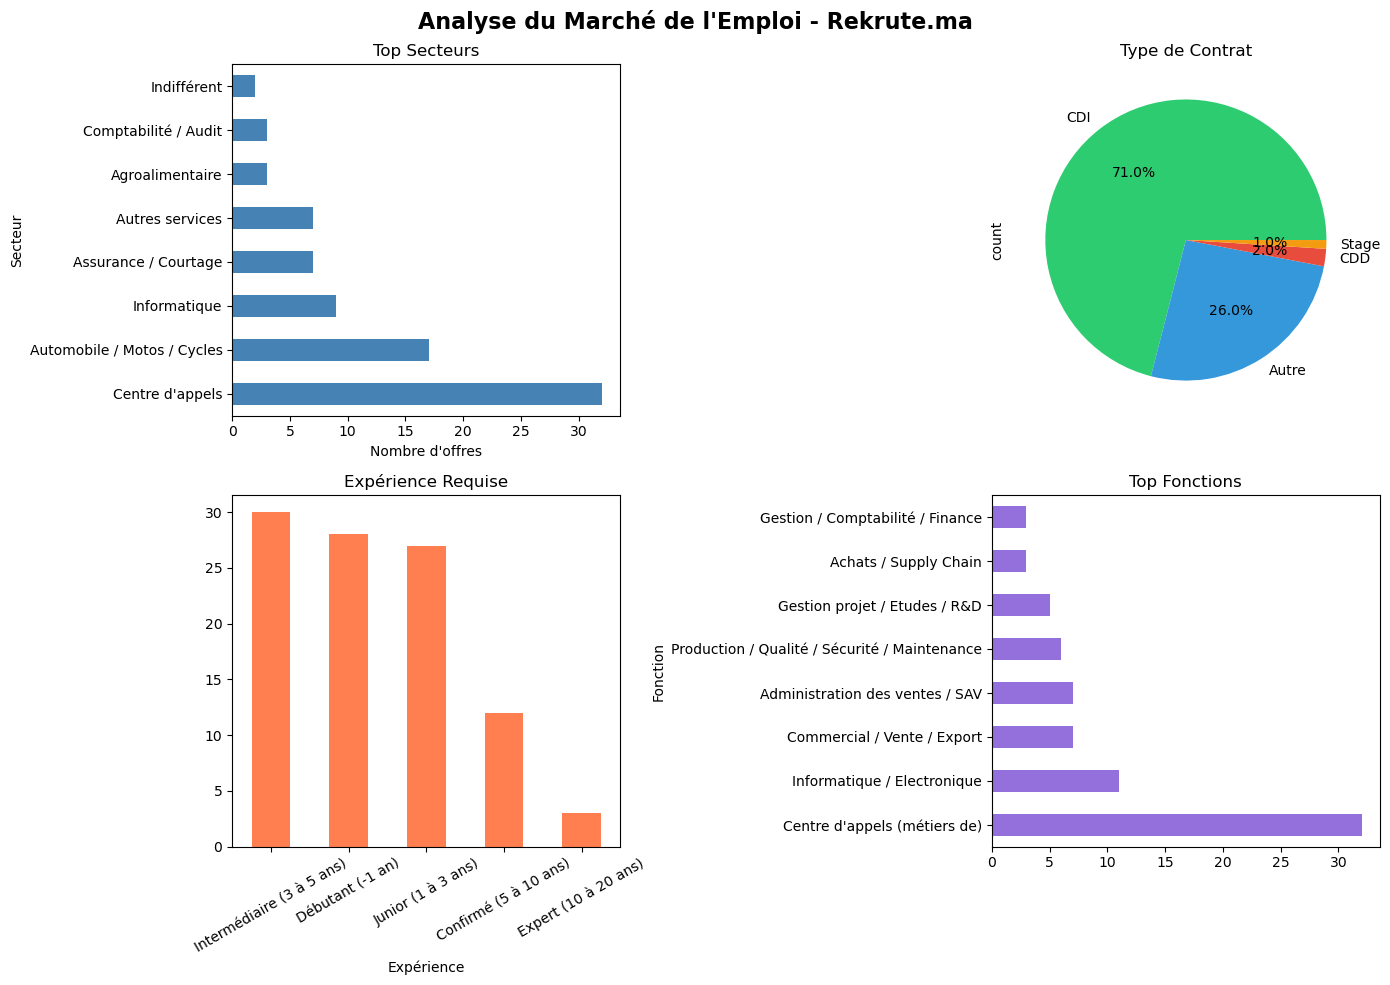

✅ تم حفظ الصورة!


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Analyse du Marché de l'Emploi - Rekrute.ma", 
             fontsize=16, fontweight="bold")

# 1. Top Secteurs
df["Secteur"].value_counts().head(8).plot(
    kind="barh", ax=axes[0,0], color="steelblue"
)
axes[0,0].set_title("Top Secteurs")
axes[0,0].set_xlabel("Nombre d'offres")

# 2. Type de Contrat
df["Contrat"].value_counts().plot(
    kind="pie", ax=axes[0,1], autopct="%1.1f%%",
    colors=["#2ecc71","#3498db","#e74c3c","#f39c12"]
)
axes[0,1].set_title("Type de Contrat")

# 3. Expérience requise
df["Expérience"].value_counts().plot(
    kind="bar", ax=axes[1,0], color="coral"
)
axes[1,0].set_title("Expérience Requise")
axes[1,0].tick_params(axis="x", rotation=30)

# 4. Top Fonctions
df["Fonction"].value_counts().head(8).plot(
    kind="barh", ax=axes[1,1], color="mediumpurple"
)
axes[1,1].set_title("Top Fonctions")

plt.tight_layout()
plt.savefig("analyse_emploi.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ تم حفظ الصورة!")

In [10]:
import sqlite3

# نبنيو database
conn = sqlite3.connect("emploi_maroc.db")

# نحطو DataFrame فيها
df.to_sql("offres", conn, if_exists="replace", index=False)

print("✅ Database created!")

# نجربو query بسيطة
query = """
SELECT Secteur, COUNT(*) as nombre
FROM offres
GROUP BY Secteur
ORDER BY nombre DESC
LIMIT 5
"""

result = pd.read_sql(query, conn)
print(result)

conn.close()

✅ Database created!
                       Secteur  nombre
0              Centre d'appels      32
1  Automobile / Motos / Cycles      17
2                 Informatique       9
3              Autres services       7
4         Assurance / Courtage       7
